# 01 - Exploratory Data Analysis (EDA)
---
**Objective:** Explore and analyze the Credit Card Fraud Detection dataset

**Contents:**
- Load the dataset
- Check for missing values and duplicates
- Analyze class distribution (fraud vs. non-fraud)
- Visualize important features
- Perform statistical analysis

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data.loader import load_data, save_file

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Python version: 3.13.5
Pandas version: 2.3.1
NumPy version: 2.3.2


In [ ]:
# Load train data
train = load_data('../data/raw/fraudTrain.csv')

👉 Loading: ../data/raw/fraudTrain.csv
DATASET INFORMATION
Shape: 1,296,675 rows × 23 columns
Memory usage: 1034.99 MB

Column types:
object     12
int64       6
float64     5
Name: count, dtype: int64

Missing values: 0


In [5]:
# Load test data
test = load_data('../data/raw/fraudTest.csv')

👉 Loading: ../data/raw/fraudTest.csv
DATASET INFORMATION
Shape: 555,719 rows × 23 columns
Memory usage: 443.58 MB

Column types:
object     12
int64       6
float64     5
Name: count, dtype: int64

Missing values: 0


## 1. Dataset Overview

In [7]:
train.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [8]:
test.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0


In [6]:
numeric_cols = train.select_dtypes(include='number').columns
object_cols = train.select_dtypes(include=['object']).columns

print("Numeric columns:", len(numeric_cols))
print("Object columns:", len(object_cols))

print("\nList of numeric columns:")
print(numeric_cols.tolist())

print("\nList of object columns:")
print(object_cols.tolist())

Numeric columns: 11
Object columns: 12

List of numeric columns:
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']

List of object columns:
['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


In [7]:
# Time range
print("Time range of transactions:")
for df in [train, test]:
    print(f"{'Train' if df is train else 'Test'} dataset:")
    print(f"Minimum time: {df['trans_date_trans_time'].min()}")
    print(f"Maximum time: {df['trans_date_trans_time'].max()}")

Time range of transactions:
Train dataset:
Minimum time: 2019-01-01 00:00:18
Maximum time: 2020-06-21 12:13:37
Test dataset:
Minimum time: 2020-06-21 12:14:25
Maximum time: 2020-12-31 23:59:34


In [9]:
# Check for duplicates
print("="*50)
print("DUPLICATE ROWS")
print("="*50)
for df in [train, test]:
    duplicates = df.duplicated().sum()
    print(f"{'Train' if df is train else 'Test'} dataset - Number of duplicate rows: {duplicates} ({(duplicates/len(df))*100:.2f}%)")

DUPLICATE ROWS
Train dataset - Number of duplicate rows: 0 (0.00%)
Test dataset - Number of duplicate rows: 0 (0.00%)


### Dataset Summary
1. Unnecessary features (can be dropped)
- `Unnamed: 0`: Index/row identifier (unnecessary column that consumes extra memory).
- `cc_num`: Credit card number (may indicate fraud but is sensitive and typically not used directly in modeling).
- `trans_num`: Unique identifier for the transaction (used for identification rather than modeling).
- `first`, `last`: Name of the cardholder (generally not useful for fraud detection).
2. Time-based features
- `trans_date_trans_time`: Date and time of the transaction (important for time-based analysis).
- `unix_time`: Transaction timestamp in Unix format Transaction timestamp in Unix format (useful for time-based fraud detection and calculations).
3. Information features
- `merchant`: Merchant where the transaction occurred (may reveal fraud linked to specific merchants).
- `category`: Category of goods or services purchased (some categories may have higher fraud risk).
- `amt`: Transaction amount (important for detecting unusually large or suspicious transactions).
- `gender`: Gender of the cardholder (may or may not contribute meaningful patterns).
- `city_pop`: Population of the city (can provide context for regional fraud patterns).
- `job`: Occupation of the cardholder (generally has low correlation with fraud).
- `dob`: Date of birth of the cardholder (can help detect age-related fraud patterns).
4. Geographic features
- `street`: Street address of the cardholder (location information).
- `city`: City of the cardholder (useful for regional fraud analysis).
- `state`: State of the cardholder (can help detect unusual location activity).
- `zip`: ZIP code of the cardholder (helps identify location inconsistencies).
- `lat`: Latitude of the cardholder's location (used in geolocation analysis).
- `long`: Longitude of the cardholder's location.
- `merch_lat`: Latitude of the merchant's location (helps compare transaction location with user location).
- `merch_long`: Longitude of the merchant's location.
5. Target variable
- `is_fraud`: Target variable (1 for fraudulent, 0 for legitimate transactions).



### Key Points:
- `is_fraud` is the target variable for fraud detection.
- `trans_date_trans_time` and `unix_time` both contain time information, but the former is easier for humans to interpret.
- Features such as `amt`, `merchant`, and location coordinates (`lat`, `long`) may play an important role in identifying fraudulent patterns.
- Personal information like `first`, `last`, and `cc_num` is sensitive and typically excluded from modeling.
- The dataset is split based on time, where the training data covers `January 2019` to `June 2020`, and the test data covers `June 2020` to `December 2020`.

In [29]:
# Drop unnecessary columns
column_del = ['Unnamed: 0', 'cc_num', 'first', 'last', 'trans_num']
print("Dropping columns:", column_del)
train.drop(columns=column_del, inplace=True)
test.drop(columns=column_del, inplace=True)
print("Columns dropped successfully!")

Dropping columns: ['Unnamed: 0', 'cc_num', 'first', 'last', 'trans_num']
Columns dropped successfully!


### Heatmap

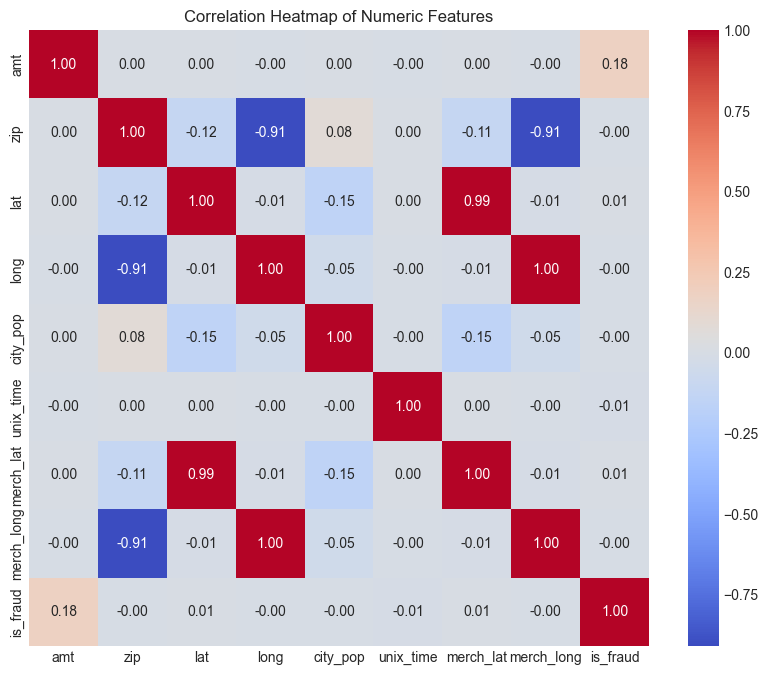

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numeric columns
num_cols = ['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 
            'merch_lat', 'merch_long', 'is_fraud']

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

**Correlation Heatmap Observations**
- Most numeric features show very weak correlation with the target variable `is_fraud`, indicating that fraud detection likely depends on complex patterns rather than single variables.
- The transaction amount `amt` has the highest correlation with fraud (≈0.18), suggesting that larger transactions are slightly more associated with fraudulent activity.
- Strong correlations appear between geographic features, particularly `lat`/`merch_lat` (≈0.99) and `long`/`merch_long` (≈1.00), which is expected since merchant and cardholder locations may be geographically related.
- ZIP code is strongly correlated with longitude (-0.91), reflecting the geographic structure of ZIP code regions.
- Overall, the heatmap suggests that feature engineering (such as distance between customer and merchant locations or time-based features) may be more useful than relying on raw numeric correlations alone.

## 2. Target Variable Analysis (Fraud Distribution)

In [12]:
# Fraud distribution
print("="*50)
print("FRAUD DISTRIBUTION")
print("="*50)
fraud_counts = train['is_fraud'].value_counts()
fraud_pct = train['is_fraud'].value_counts(normalize=True) * 100

print("\nCount:")
print(fraud_counts)
print("\nPercentage:")
print(fraud_pct)

FRAUD DISTRIBUTION

Count:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


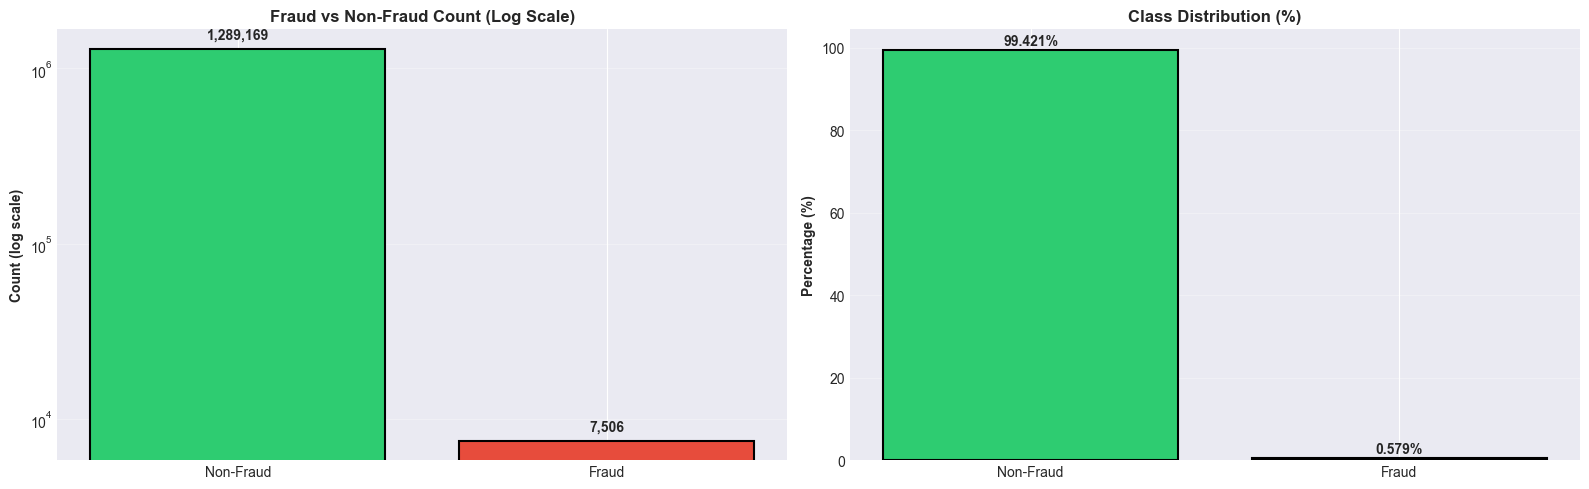

In [13]:
# Visualize with better approach for imbalanced data
fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 2)

# Count plot with log scale
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(['Non-Fraud', 'Fraud'], fraud_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Count (log scale)', fontweight='bold')
ax1.set_title('Fraud vs Non-Fraud Count (Log Scale)', fontweight='bold', fontsize=12)
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)
# Add value labels
for i, (bar, v) in enumerate(zip(bars, fraud_counts.values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height * 1.1, f'{v:,}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# Percentage comparison
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(['Non-Fraud', 'Fraud'], fraud_pct.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Percentage (%)', fontweight='bold')
ax2.set_title('Class Distribution (%)', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
# Add value labels
for bar, v in zip(bars2, fraud_pct.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{v:.3f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

imbalance_ratio = fraud_counts[0] / fraud_counts[1]

In [14]:
print(f"\n{'='*50}")
print(f"⚠️  SEVERE CLASS IMBALANCE DETECTED!")
print(f"{'='*50}")
print(f"➤ Imbalance Ratio: 1:{imbalance_ratio:.2f}")
print(f"➤ For every 1 fraud transaction, there are ~{imbalance_ratio:.0f} legitimate transactions")
print(f"➤ This requires special handling during model training!")


⚠️  SEVERE CLASS IMBALANCE DETECTED!
➤ Imbalance Ratio: 1:171.75
➤ For every 1 fraud transaction, there are ~172 legitimate transactions
➤ This requires special handling during model training!


## 3. Geographic Distribution

### 3.1 Distance (km)

Calculate distance from customer to merchant using 4 columns:
- `lat`
- `long`
- `merch_lat`
- `merch_long`

Then create a new feature: `distance_km`.

In [15]:
geo_df = train[['is_fraud', 'lat', 'long', 'merch_lat', 'merch_long']].copy()

earth_radius_km = 6371.0
lat1 = np.radians(geo_df['lat'])
lon1 = np.radians(geo_df['long'])
lat2 = np.radians(geo_df['merch_lat'])
lon2 = np.radians(geo_df['merch_long'])

delta_lat = lat2 - lat1
delta_lon = lon2 - lon1
a = np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2
c = 2 * np.arcsin(np.sqrt(a))

train['distance_km'] = earth_radius_km * c

print("Distance calculation completed successfully!")

Distance calculation completed successfully!


### 3.2 Location correlation analysis

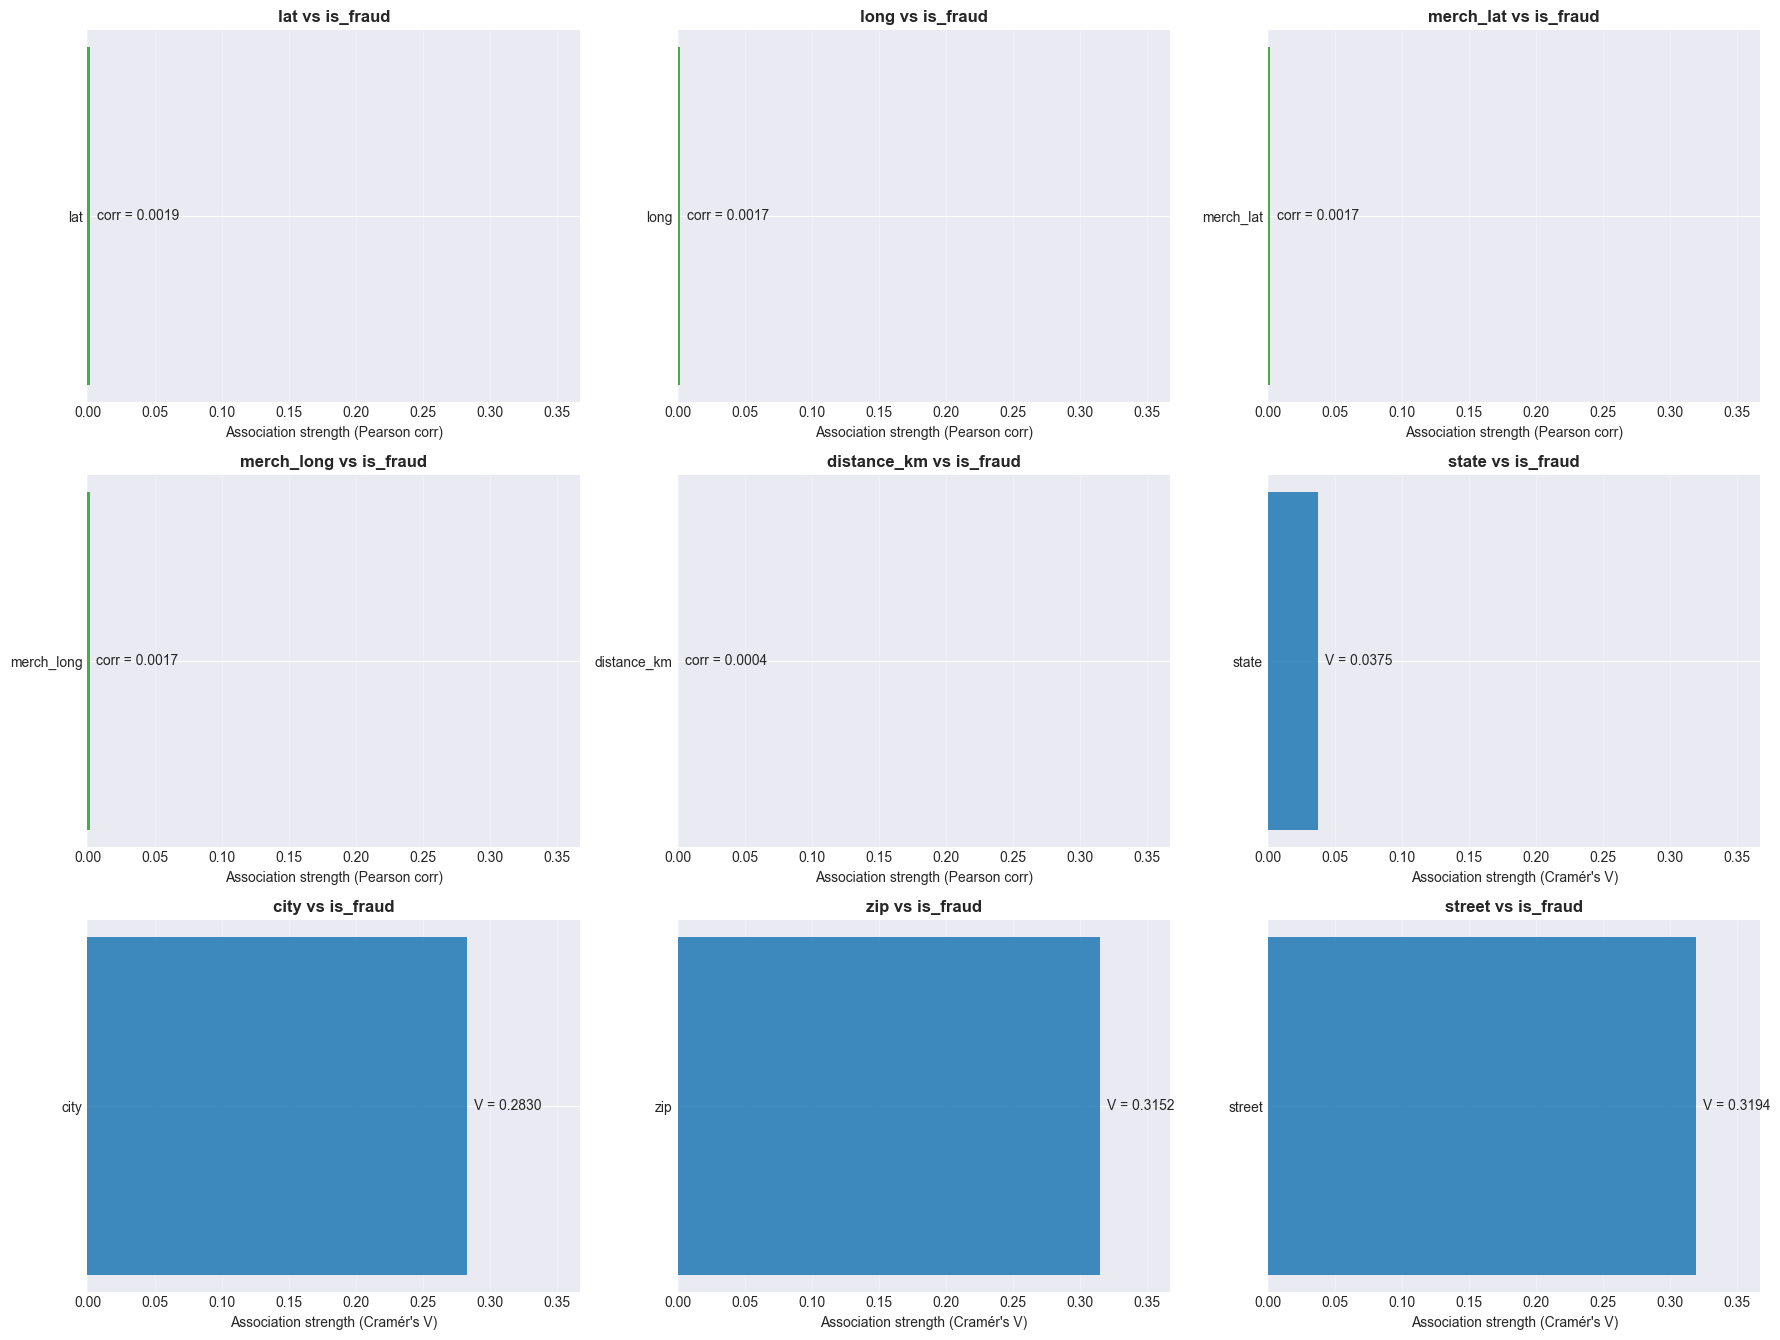

In [16]:
from scipy.stats import chi2_contingency

# Columns related to location
loc_cat_cols = ['state', 'city', 'zip', 'street']
loc_num_cols = ['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']

# Numeric correlation with target (Pearson / point-biserial because is_fraud is binary)
num_corr = train[loc_num_cols + ['is_fraud']].corr(numeric_only=True)['is_fraud'].drop('is_fraud')

def cramers_v(x, y):
    """Compute bias-corrected Cramer's V for two categorical variables."""
    ct = pd.crosstab(x, y)
    if ct.empty or min(ct.shape) < 2:
        return np.nan

    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.to_numpy().sum()
    if n <= 1:
        return np.nan

    phi2 = chi2 / n
    r, k = ct.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)

    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

# Categorical association with target
cat_assoc = {col: cramers_v(train[col].astype(str), train['is_fraud']) for col in loc_cat_cols}

# Build one record per feature for plotting separately
feature_rows = []
for col in loc_num_cols:
    feature_rows.append({
        'feature': col,
        'metric': 'Pearson corr',
        'value': num_corr[col],
        'plot_value': abs(num_corr[col])
    })

for col in loc_cat_cols:
    val = cat_assoc[col]
    feature_rows.append({
        'feature': col,
        'metric': "Cramér's V",
        'value': val,
        'plot_value': val
    })

feature_assoc_df = pd.DataFrame(feature_rows)

# Plot each feature separately against is_fraud
n_features = len(feature_assoc_df)
ncols = 3
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for i, row in feature_assoc_df.iterrows():
    ax = axes[i]
    feat = row['feature']
    metric = row['metric']
    value = row['value']
    plot_value = row['plot_value']

    # Color by sign for Pearson, fixed color for Cramer's V
    if metric == 'Pearson corr':
        color = '#2ca02c' if value >= 0 else '#d62728'
        label = f"corr = {value:.4f}"
    else:
        color = '#1f77b4'
        label = f"V = {value:.4f}"

    ax.barh([feat], [plot_value], color=color, alpha=0.85)
    ax.set_xlim(0, max(0.35, feature_assoc_df['plot_value'].max() * 1.15))
    ax.set_title(f"{feat} vs is_fraud", fontweight='bold')
    ax.set_xlabel(f"Association strength ({metric})")
    ax.grid(axis='x', alpha=0.25)

    ax.text(plot_value + 0.005, 0, label, va='center', fontsize=10)

# Hide unused subplots if any
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [17]:
print('\nAssociation summary:')
display(feature_assoc_df.sort_values('plot_value', ascending=False).reset_index(drop=True))


Association summary:


,feature,metric,value,plot_value
0,street,Cramér's V,0.319431,0.319431
1,zip,Cramér's V,0.315177,0.315177
2,city,Cramér's V,0.283046,0.283046
3,state,Cramér's V,0.037458,0.037458
4,lat,Pearson corr,0.001894,0.001894
5,merch_lat,Pearson corr,0.001741,0.001741
6,merch_long,Pearson corr,0.001721,0.001721
7,long,Pearson corr,0.001721,0.001721
8,distance_km,Pearson corr,0.000403,0.000403


**Location Analysis Conclusion:**
- Coordinate features (`lat`, `long`, `merch_lat`, `merch_long`) and `distance_km` show very weak association with `is_fraud`.
- Categorical location features are more informative, especially `street`, `zip`, and `city`.
- `state` contributes less than the other location categories.
- `distance_km` can replace raw coordinates to reduce feature redundancy, but model testing is recommended to confirm its usefulness.

## 4. Time Analysis

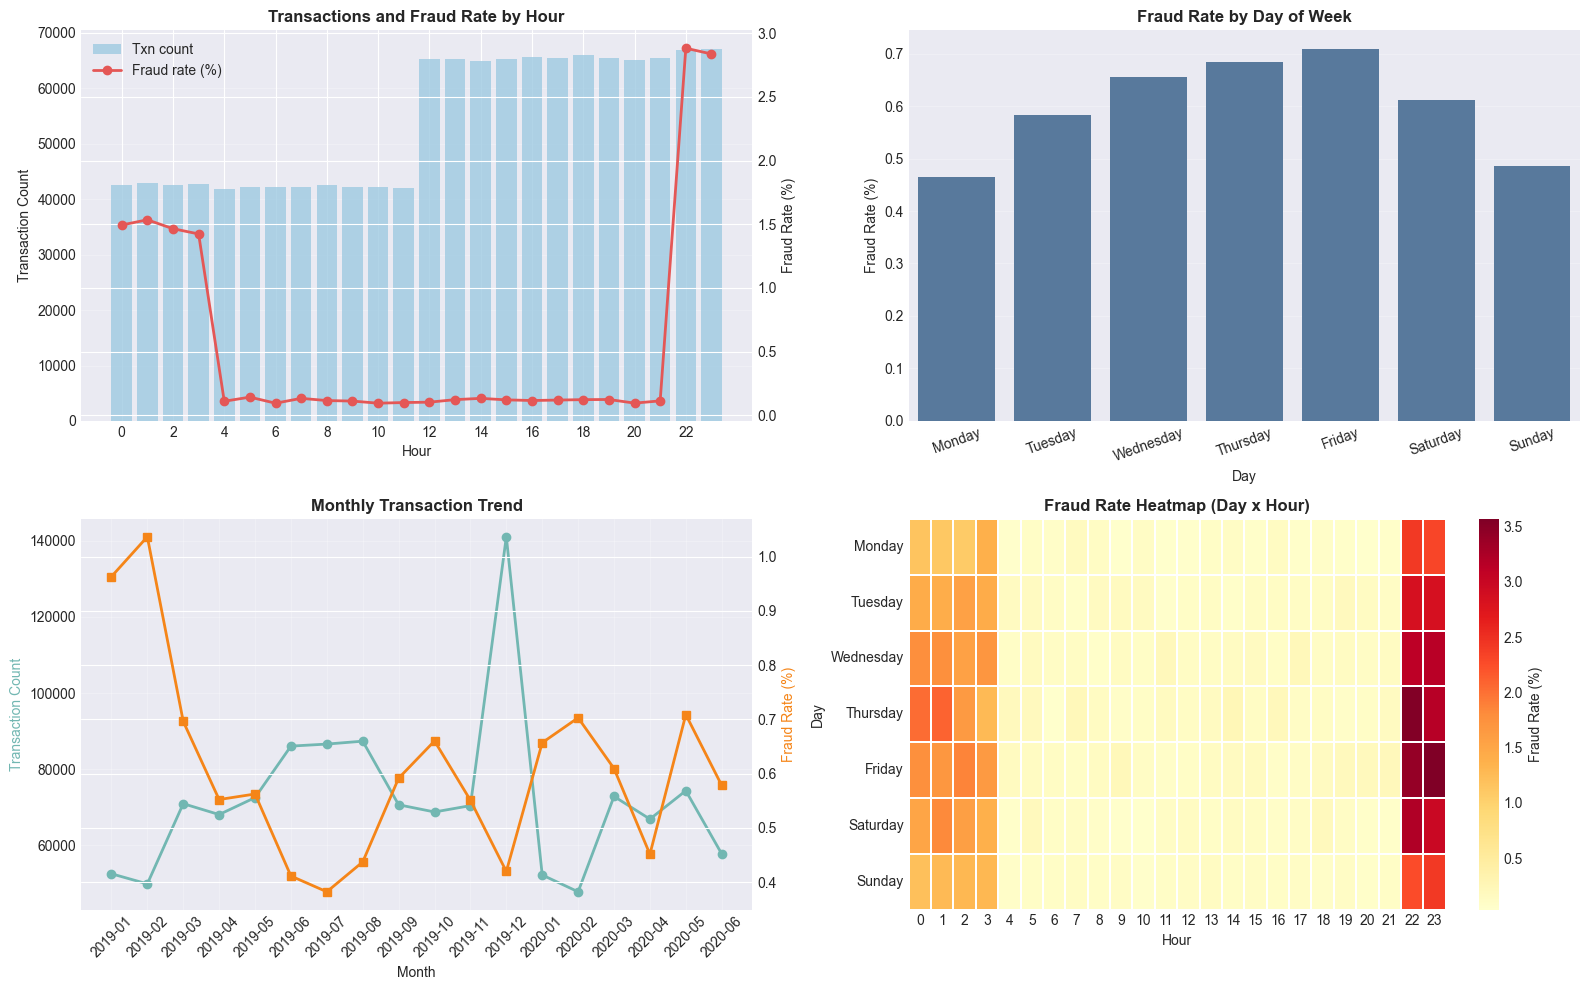

In [18]:
'''
Comprehensive Time Analysis: trans datetime, unix_time, and optional DOB-derived age
'''
# 1) Build base dataframe and parse datetime
time_df = train[['trans_date_trans_time', 'unix_time', 'is_fraud']].copy()
time_df['trans_datetime'] = pd.to_datetime(time_df['trans_date_trans_time'], errors='coerce')
time_df['unix_time_num'] = pd.to_numeric(time_df['unix_time'], errors='coerce')

# 2) Create time features
time_df['hour'] = time_df['trans_datetime'].dt.hour
time_df['day_name'] = pd.Categorical(
    time_df['trans_datetime'].dt.day_name(),
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)
time_df['month'] = time_df['trans_datetime'].dt.to_period('M').astype(str)
time_df['is_weekend'] = time_df['day_name'].isin(['Saturday', 'Sunday']).astype(int)

# 3) Core aggregations
hourly_count = time_df.groupby('hour', observed=True).size().reindex(range(24), fill_value=0)
fraud_rate_by_hour = (time_df.groupby('hour', observed=True)['is_fraud'].mean() * 100).reindex(range(24))

fraud_rate_by_day = (time_df.groupby('day_name', observed=True)['is_fraud'].mean() * 100)
tx_count_by_day = time_df.groupby('day_name', observed=True).size()

month_agg = (
    time_df.groupby('month', observed=True)
    .agg(tx_count=('is_fraud', 'size'), fraud_rate_pct=('is_fraud', lambda s: s.mean() * 100))
    .reset_index()
    .sort_values('month')
)
# Day x hour fraud-rate heatmap
heatmap_df = (
    time_df.groupby(['day_name', 'hour'], observed=True)['is_fraud']
    .mean()
    .mul(100)
    .unstack(fill_value=np.nan)
    .reindex(index=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
)

# 7) Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# (a) Hour: count + fraud rate
ax = axes[0, 0]
ax.bar(hourly_count.index, hourly_count.values, color='#9ecae1', alpha=0.8, label='Txn count')
ax.set_title('Transactions and Fraud Rate by Hour', fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Transaction Count')
ax.set_xticks(range(0, 24, 2))
ax.grid(axis='y', alpha=0.25)

ax_r = ax.twinx()
ax_r.plot(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='#e45756', marker='o', linewidth=2, label='Fraud rate (%)')
ax_r.set_ylabel('Fraud Rate (%)')
# Combine legends from both axes
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax_r.legend(lines + lines2, labels + labels2, loc='upper left')

# (b) Day of week fraud rate
sns.barplot(x=fraud_rate_by_day.index, y=fraud_rate_by_day.values, ax=axes[0, 1], color='#4c78a8')
axes[0, 1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Fraud Rate (%)')
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].grid(axis='y', alpha=0.25)

# (c) Monthly trend (count + fraud rate)
axes[1, 0].plot(month_agg['month'], month_agg['tx_count'], marker='o', color='#72b7b2', linewidth=2)
axes[1, 0].set_title('Monthly Transaction Trend', fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Transaction Count', color='#72b7b2')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(alpha=0.25)

ax2 = axes[1, 0].twinx()
ax2.plot(month_agg['month'], month_agg['fraud_rate_pct'], marker='s', color='#f58518', linewidth=2)
ax2.set_ylabel('Fraud Rate (%)', color='#f58518')

# (d) Day x Hour fraud-rate heatmap
sns.heatmap(heatmap_df, cmap='YlOrRd', linewidths=0.3, ax=axes[1, 1], cbar_kws={'label': 'Fraud Rate (%)'})
axes[1, 1].set_title('Fraud Rate Heatmap (Day x Hour)', fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Day')

plt.tight_layout()
plt.show()

In [19]:
# Compact summary table
top_hours = fraud_rate_by_hour.sort_values(ascending=False).head(3)
top_days = fraud_rate_by_day.sort_values(ascending=False).head(3)

print('Comprehensive Time Analysis completed!')
print('Top 3 risky hours (%):')
print(top_hours.round(3))
print('\nTop 3 risky days (%):')
print(top_days.round(3))

Comprehensive Time Analysis completed!
Top 3 risky hours (%):
hour
22    2.883
23    2.837
1     1.535
Name: is_fraud, dtype: float64

Top 3 risky days (%):
day_name
Friday       0.709
Thursday     0.684
Wednesday    0.655
Name: is_fraud, dtype: float64


**Time Analysis Conclusion:**
- Time-related features are informative, as fraud rates vary by hour, day, and month.
- Fraud occurs more frequently late at night, with the highest rates around 22:00–23:00, while daytime hours show lower fraud activity.
- By day of the week, Friday, Thursday, and Wednesday have the highest fraud rates.
- Monthly trends show fluctuations in both transaction volume and fraud rate, suggesting that fraud patterns change over time.

Overall, time-based features are useful predictors and should be included in the fraud detection model.

## 5. Infomation features

In [30]:
# Information features
feature_df = train[['amt', 'gender', 'category', 'merchant', 'city_pop', 'job', 'is_fraud', 'dob']].copy()

### 5.1 Transaction Amount `amt`

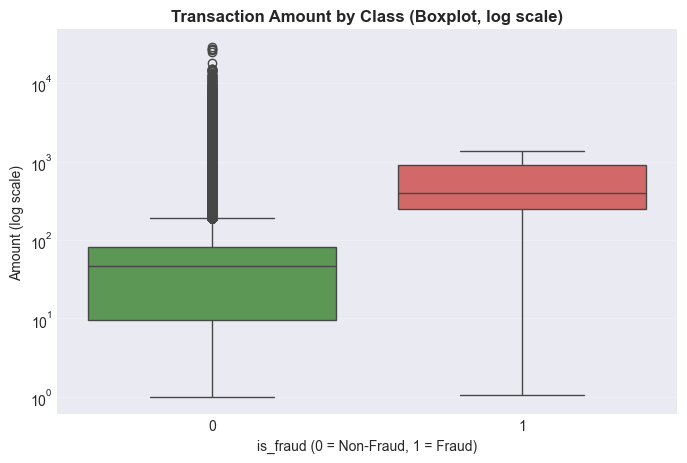

In [21]:
# Simple Transaction Amount analysis
feature_df['amt'] = pd.to_numeric(feature_df['amt'], errors='coerce')
feature_df = feature_df.dropna(subset=['amt', 'is_fraud'])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=feature_df,
    x='is_fraud',
    y='amt',
    palette=['#54a24b', '#e45756']
)
plt.yscale('log')
plt.title('Transaction Amount by Class (Boxplot, log scale)', fontweight='bold')
plt.xlabel('is_fraud (0 = Non-Fraud, 1 = Fraud)')
plt.ylabel('Amount (log scale)')
plt.grid(axis='y', alpha=0.25)
plt.show()

### 5.2 `gender` and `dob`

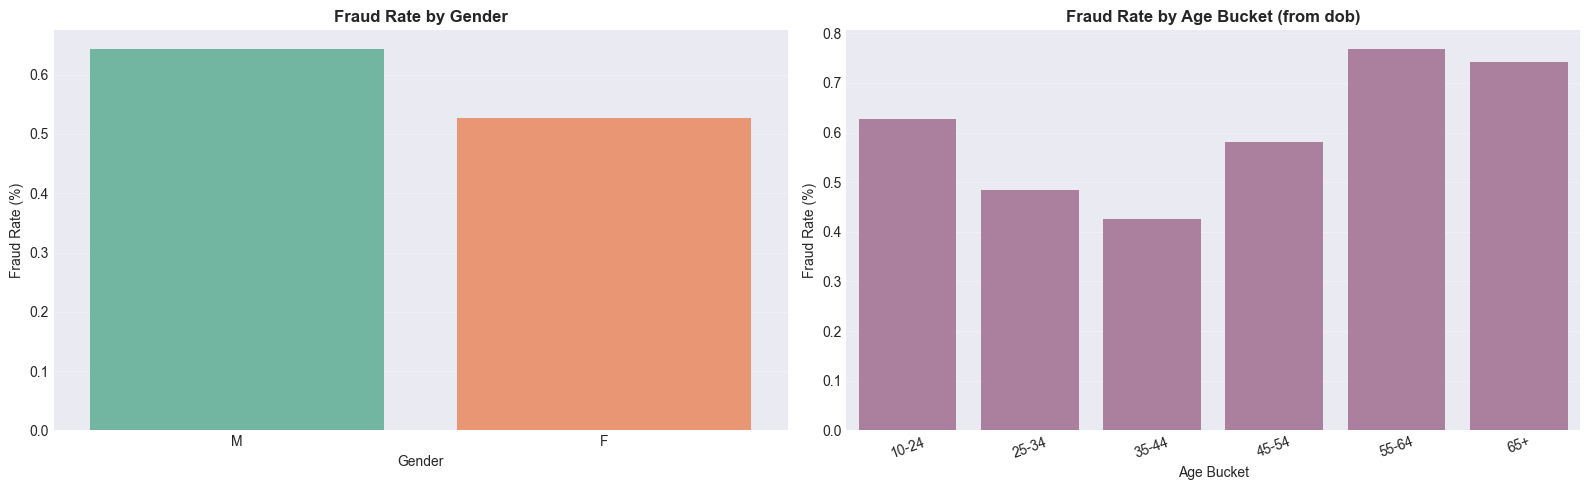

In [31]:
# Gender and DOB analysis
gender_rate = feature_df.groupby('gender')['is_fraud'].mean().mul(100).sort_values(ascending=False)

dob_df = feature_df[['dob', 'is_fraud']].copy()
dob_df['trans_date'] = pd.to_datetime(train['trans_date_trans_time'], errors='coerce')
dob_df['dob_dt'] = pd.to_datetime(dob_df['dob'], errors='coerce')
age_years = (dob_df['trans_date'] - dob_df['dob_dt']).dt.days / 365.25
dob_df['age_years'] = age_years.where((age_years >= 10) & (age_years <= 100))
age_bins = [10, 25, 35, 45, 55, 65, 100]
age_labels = ['10-24', '25-34', '35-44', '45-54', '55-64', '65+']
dob_df['age_bucket'] = pd.cut(dob_df['age_years'], bins=age_bins, labels=age_labels, right=False)
age_rate = (
    dob_df.groupby('age_bucket', observed=True)['is_fraud']
    .mean()
    .mul(100)
    .reindex(age_labels)
    .fillna(0)
 )

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=gender_rate.index, y=gender_rate.values, ax=axes[0], palette='Set2')
axes[0].set_title('Fraud Rate by Gender', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].grid(axis='y', alpha=0.25)

sns.barplot(x=age_rate.index.astype(str), y=age_rate.values, ax=axes[1], color='#b279a2')
axes[1].set_title('Fraud Rate by Age Bucket (from dob)', fontweight='bold')
axes[1].set_xlabel('Age Bucket')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

### 5.3 `city_pop` and `job`

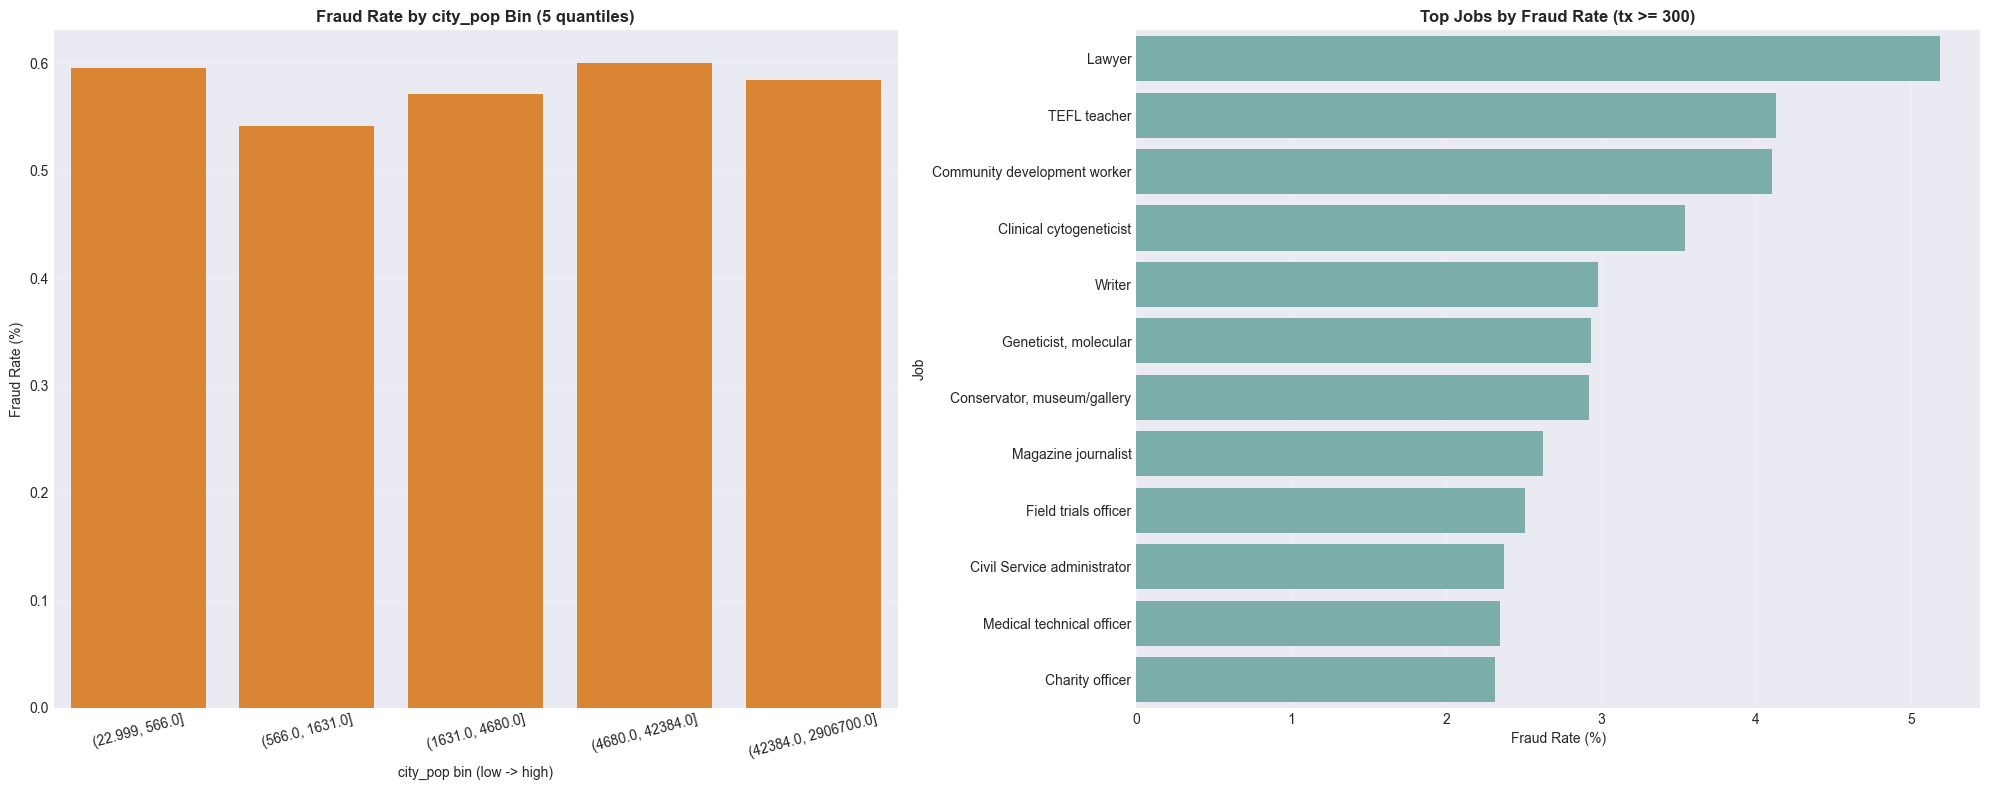

In [32]:
# city_pop and job analysis
city_df = feature_df[['city_pop', 'is_fraud']].copy()
city_df['city_pop'] = pd.to_numeric(city_df['city_pop'], errors='coerce')
city_df = city_df.dropna(subset=['city_pop'])

city_df['city_pop_bin'] = pd.qcut(city_df['city_pop'], q=5, duplicates='drop')
city_plot = (
    city_df.groupby('city_pop_bin', observed=True)['is_fraud']
    .mean()
    .mul(100)
    .reset_index(name='fraud_rate_pct')
)
city_plot['bin_label'] = city_plot['city_pop_bin'].astype(str)

def top_group_fraud_rate(data, col, min_tx=300, top_n=12):
    temp = (
        data.groupby(col)
        .agg(tx_count=('is_fraud', 'size'), fraud_rate_pct=('is_fraud', lambda s: s.mean() * 100))
        .reset_index()
    )
    temp = temp[temp['tx_count'] >= min_tx]
    return temp.sort_values('fraud_rate_pct', ascending=False).head(top_n)

job_plot = top_group_fraud_rate(feature_df, 'job', min_tx=300, top_n=12)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=city_plot, x='bin_label', y='fraud_rate_pct', color='#f58518', ax=axes[0])
axes[0].set_title('Fraud Rate by city_pop Bin (5 quantiles)', fontweight='bold')
axes[0].set_xlabel('city_pop bin (low -> high)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.25)

sns.barplot(data=job_plot, y='job', x='fraud_rate_pct', ax=axes[1], color='#72b7b2')
axes[1].set_title('Top Jobs by Fraud Rate (tx >= 300)', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Job')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

### 5.4 `merchant` and `category`

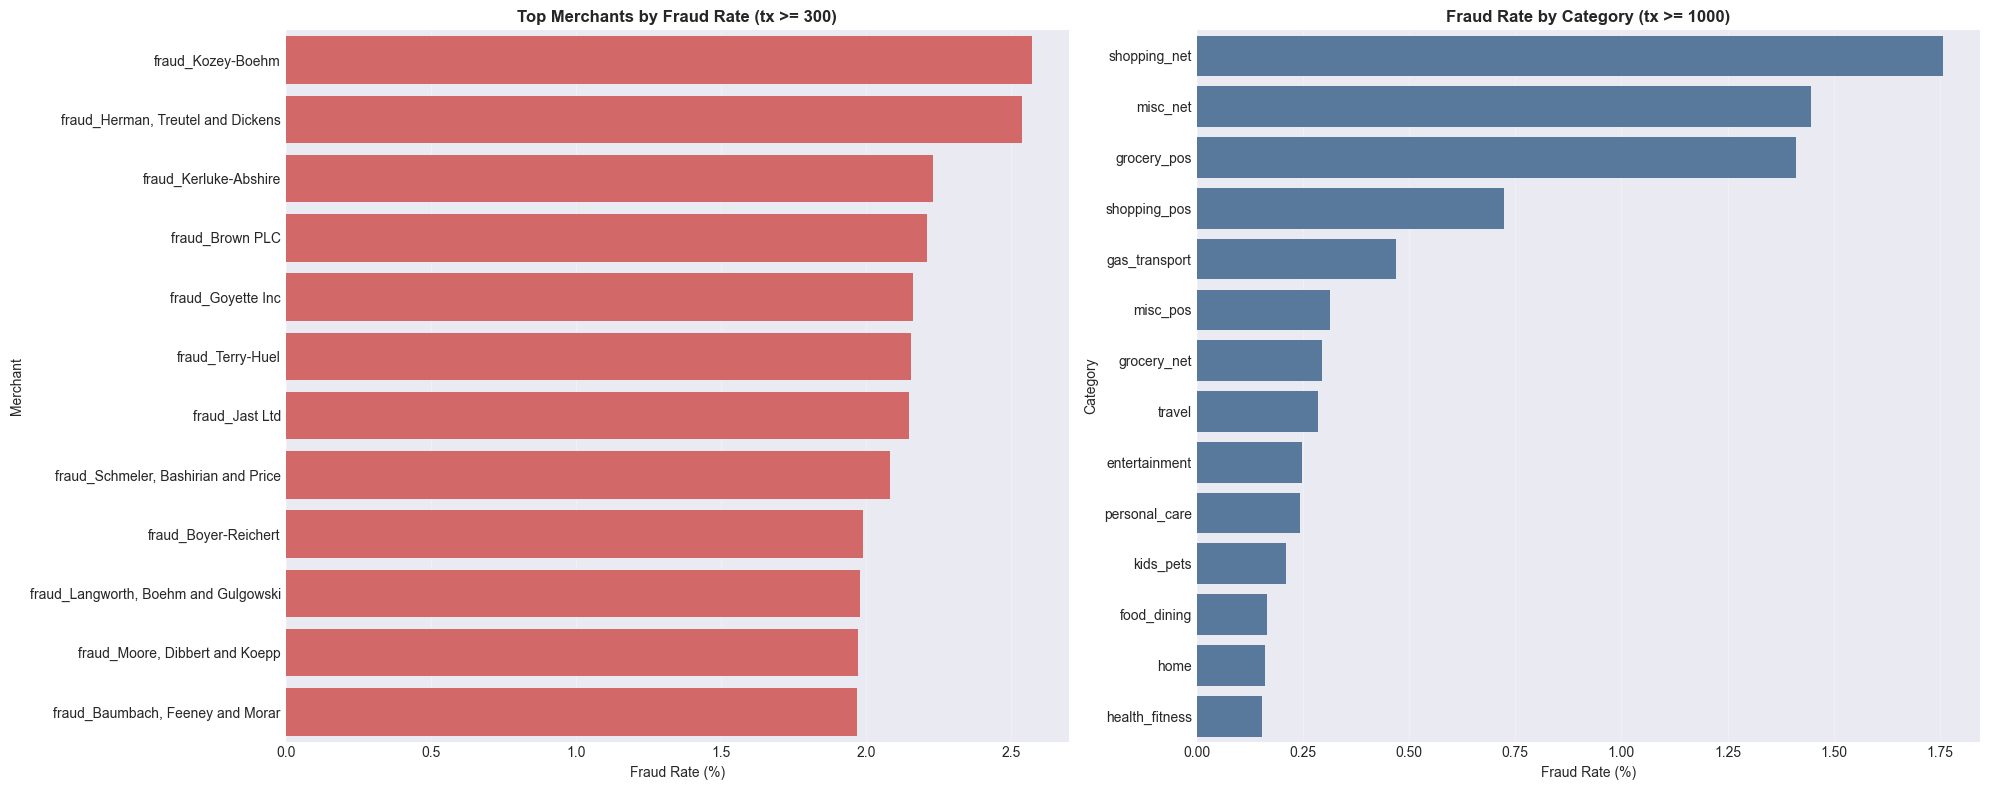

In [33]:
# merchant and category analysis
def top_group_fraud_rate(data, col, min_tx=300, top_n=12):
    temp = (
        data.groupby(col)
        .agg(tx_count=('is_fraud', 'size'), fraud_rate_pct=('is_fraud', lambda s: s.mean() * 100))
        .reset_index()
    )
    temp = temp[temp['tx_count'] >= min_tx]
    return temp.sort_values('fraud_rate_pct', ascending=False).head(top_n)

merchant_plot = top_group_fraud_rate(feature_df, 'merchant', min_tx=300, top_n=12)

cat_stats = (
    feature_df.groupby('category')
    .agg(tx_count=('is_fraud', 'size'), fraud_rate_pct=('is_fraud', lambda s: s.mean() * 100))
    .reset_index()
)
cat_plot = cat_stats[cat_stats['tx_count'] >= 1000].sort_values('fraud_rate_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=merchant_plot, y='merchant', x='fraud_rate_pct', ax=axes[0], color='#e45756')
axes[0].set_title('Top Merchants by Fraud Rate (tx >= 300)', fontweight='bold')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].set_ylabel('Merchant')
axes[0].grid(axis='x', alpha=0.25)

sns.barplot(data=cat_plot, y='category', x='fraud_rate_pct', ax=axes[1], color='#4c78a8')
axes[1].set_title('Fraud Rate by Category (tx >= 1000)', fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].set_ylabel('Category')
axes[1].grid(axis='x', alpha=0.25)

plt.tight_layout()
plt.show()

## 6. General Conclusion
- The dataset is **highly imbalanced**, with fraudulent transactions representing a very small proportion of the data. Therefore, model training should apply imbalance-aware techniques such as resampling or class-weighted algorithms.
- **Time-based features are informative**, as fraud rates vary by hour and day. Fraudulent transactions occur more frequently during late-night hours (around 22:00–23:00) and slightly more during mid-to-late weekdays.
- **Transaction amount** `amt` is one of the most important indicators, with fraudulent transactions generally involving larger amounts than normal transactions.
- **Geographic coordinates** `lat`, `long`, `merch_lat`, `merch_long` show very weak direct correlation with fraud, but categorical location features such as `city`, `zip`, and `street` show stronger associations, suggesting regional patterns in fraud behavior.
- The engineered `distance_km` feature captures the spatial relationship between the cardholder and merchant, which may help represent geographic behavior more effectively than raw coordinates.
- Other categorical features such as `merchant`, `category`, and `job` may also provide useful signals when properly encoded.

**Recommended next step:** focus on feature engineering, particularly from `amt`, time-related variables, geographic relationships (e.g., `distance_km`), and encoded categorical features before proceeding with model training.